# Automatic Resume Screening System

Automatic Resume Screening System Using Natural Language Processing and Machine Learning

## 1. Objective

This project presents the design and implementation of an automatic resume screening system capable of classifying resumes by professional category and ranking candidates based on their suitability for a specified job description.

The system addresses a well-known challenge in human resource management: the manual evaluation of large volumes of applicant resumes is time-consuming and prone to subjective bias. By applying Natural Language Processing (NLP) and supervised machine learning techniques, this system automates the initial screening stage of recruitment.

**The core objectives of this implementation are:**

1. Load and explore a structured resume dataset.
2. Apply systematic text preprocessing to normalise resume content.
3. Transform cleaned text into numerical feature vectors using TF-IDF.
4. Train a Linear Support Vector Machine (LinearSVC) classifier to predict resume categories.
5. Rank all resumes in the dataset against a user-defined job description using cosine similarity.
6. Present the top-ranked candidates along with their match percentage and predicted category.

---

## 2. Environment Setup

The following cell imports all required libraries and downloads the necessary NLTK resources. Standard libraries only are used to ensure reproducibility and portability.

In [24]:
#Standard library
import os
import re
import pickle
import warnings
from pathlib import Path

#Data 
import numpy as np
import pandas as pd

#Visualisation 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11

#NLP
import nltk

#Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.naive_bayes     import MultinomialNB
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC
from sklearn.metrics         import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

#Project paths
BASE_DIR   = Path(r'c:\Users\srija\OneDrive\Desktop\Resume Screening')
DATA_PATH  = BASE_DIR / 'Resume.csv'
MODEL_DIR  = BASE_DIR / 'models'
PLOTS_DIR  = BASE_DIR / 'plots'
MODEL_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODEL_DIR / 'best_model.pkl'
TFIDF_PATH = MODEL_DIR / 'tfidf_vectorizer.pkl'
RANDOM_STATE   = 42
TEST_SIZE      = 0.20
CV_FOLDS       = 5
TFIDF_FEATURES = 5000
TFIDF_NGRAM    = (1, 2)

print('Imports complete.')
print(f'Dataset path : {DATA_PATH}')
print(f'Models dir   : {MODEL_DIR}')

NLTK_PACKAGES = [
    ('tokenizers/punkt',          'punkt'),
    ('tokenizers/punkt_tab',      'punkt_tab'),
    ('corpora/stopwords',         'stopwords'),
    ('corpora/wordnet',           'wordnet'),
    ('corpora/omw-1.4',           'omw-1.4'),
]

for data_path, pkg_name in NLTK_PACKAGES:
    try:
        nltk.data.find(data_path)
        print(f'{pkg_name} already present')
    except LookupError:
        print(f'Downloading {pkg_name}...')
        nltk.download(pkg_name, quiet=True)
        print(f'{pkg_name} downloaded')

from nltk.corpus   import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem     import WordNetLemmatizer


from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print('NLTK resources ready!')

Imports complete.
Dataset path : c:\Users\srija\OneDrive\Desktop\Resume Screening\Resume.csv
Models dir   : c:\Users\srija\OneDrive\Desktop\Resume Screening\models
punkt already present
punkt_tab already present
stopwords already present
wordnet downloaded
omw-1.4 downloaded
NLTK resources ready!


## 3. Data Loading

The dataset is loaded from a CSV file. It contains the following columns:

| Column | Description |
|---|---|
| `ID` | Unique numeric identifier for each candidate |
| `Resume_str` | Plain-text version of the resume (used for all ML operations) |
| `Resume_html` | HTML-formatted version of the resume (reserved for future UI use) |
| `Category` | Target label representing the professional domain |

The column `Resume_str` is used directly as the primary text input for all machine learning operations. The `Resume_html` column is retained but not used in any ML pipeline steps.

In [25]:
# Load the dataset
# Update the file path below if the dataset is located in a different directory
df = pd.read_csv('Resume.csv')

print(f"Dataset loaded successfully.")
print(f"Total records      : {len(df)}")
print(f"Columns available  : {list(df.columns)}")
print(f"Target categories  : {df['Category'].nunique()} unique categories")
print()
df.head()

Dataset loaded successfully.
Total records      : 2484
Columns available  : ['ID', 'Resume_str', 'Resume_html', 'Category']
Target categories  : 24 unique categories



,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [26]:
# Examine dataset structure and check for missing values
print("Dataset Shape:", df.shape)
print()
print("Missing Values Per Column:")
print(df.isnull().sum())
print()
print("Category Distribution:")
print(df['Category'].value_counts())

Dataset Shape: (2484, 4)

Missing Values Per Column:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Category Distribution:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


## 4. Text Preprocessing

Raw resume text contains significant noise — including email addresses, URLs, special characters, and numerals — that does not contribute to the semantic meaning relevant for classification. A systematic preprocessing pipeline is defined to normalise all text before feature extraction.

**Preprocessing steps applied:**

1. Convert text to lowercase to ensure case-insensitive matching.
2. Remove email addresses using a regular expression pattern.
3. Remove hyperlinks and URLs.
4. Remove digits and numeric tokens.
5. Remove special characters and punctuation, retaining only alphabetic tokens.
6. Remove English stopwords using NLTK's standard stopword list.
7. Apply lemmatisation to reduce inflected words to their base form.

In [1]:

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Keep technical symbols (C++, C#, .NET) before removing punctuation

    text = re.sub(r'\bc\+\+\b', 'cpp', text)
    text = re.sub(r'\bc#\b', 'csharp', text)
    text = re.sub(r'\.net\b', 'dotnet', text)
    
    # 3. Remove punctuation but keep alphanumeric characters
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    
    # 4. Tokenize and Remove Stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    
    # Filter words: Keep technical terms even if they are short
    # Usually, NLTK removes anything < 3 chars, but we want 'R', 'AI', 'ML'
    cleaned_words = [w for w in words if w not in stop_words or len(w) <= 2]
    
    # 5. Lemmatization
    lemmatizer = WordNetLemmatizer()
    final_words = [lemmatizer.lemmatize(w) for w in cleaned_words]
    
    return " ".join(final_words)

In [28]:
# Apply preprocessing pipeline to the entire dataset
print("Applying text preprocessing to all resumes.")
df['cleaned'] = df['Resume_str'].apply(preprocess_text)

print(f"Preprocessing complete. {len(df)} resumes processed.")
print()
print("Sample — original text (first 200 characters):")
print(df['Resume_str'].iloc[0][:200])
print()
print("Sample — cleaned text (first 200 characters):")
print(df['cleaned'].iloc[0][:200])

Applying text preprocessing to all resumes.
Preprocessing complete. 2484 resumes processed.

Sample — original text (first 200 characters):
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp

Sample — cleaned text (first 200 characters):
hr administrator marketing associate hr administrator summary dedicated customer service manager 15 year of experience in hospitality customer service management respected builder leader of customer f


## 5. Feature Engineering — TF-IDF Vectorisation

Term Frequency-Inverse Document Frequency (TF-IDF) is a well-established numerical representation technique for text data. It assigns higher weights to terms that are frequent within a document but rare across the entire corpus, thereby highlighting discriminative tokens.

**Configuration used:**

- `ngram_range=(1, 2)` — captures both unigrams and bigrams to retain short multi-word phrases.
- `max_features=5000` — limits the vocabulary to the 5,000 most informative terms to control dimensionality.
- `sublinear_tf=True` — applies logarithmic scaling to term frequencies to reduce the effect of very high-frequency terms.

In [29]:
# Encode target labels
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Category'])

print("Label encoding complete.")
print(f"Number of unique categories: {len(label_encoder.classes_)}")
print(f"Categories: {list(label_encoder.classes_)}")

Label encoding complete.
Number of unique categories: 24
Categories: ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']


In [30]:
# ── Train / test split ────────────────────────────────────────────────────
X = df['cleaned']
y = df['Category']
CLASSES = sorted(y.unique())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    stratify     = y,
    random_state = RANDOM_STATE,
)

print(f'Train size : {len(X_train)}')
print(f'Test  size : {len(X_test)}')
print(f'Categories : {len(CLASSES)}')

# ── Fit TF-IDF ────────────────────────────────────────────────────────────
vectorizer = TfidfVectorizer(
    max_features  = TFIDF_FEATURES,
    ngram_range   = TFIDF_NGRAM,
    stop_words    = 'english',
    sublinear_tf  = True,    # log(1+tf) — dampens extreme frequencies
    min_df        = 2,       # ignore terms in < 2 documents
    strip_accents = 'unicode',
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f'\nTF-IDF matrix — train : {X_train_tfidf.shape}')
print(f'TF-IDF matrix — test  : {X_test_tfidf.shape}')

Train size : 1987
Test  size : 497
Categories : 24

TF-IDF matrix — train : (1987, 5000)
TF-IDF matrix — test  : (497, 5000)


## 6. Model Training — Linear Support Vector Machine

A Linear Support Vector Machine (LinearSVC) is selected for the classification task. Linear SVM is well-suited to high-dimensional, sparse feature spaces such as those produced by TF-IDF vectorisation. It is computationally efficient, highly interpretable, and consistently achieves strong performance on text classification benchmarks.

The dataset is split into training and testing subsets with an 80/20 ratio, with stratification applied to ensure proportional representation of all categories in both splits.

In [31]:
MODELS = {
    'Naive Bayes'         : MultinomialNB(alpha=0.1),
    'Logistic Regression' : LogisticRegression(
                                max_iter=2000, C=1.0,
                                solver='lbfgs',
                                random_state=RANDOM_STATE),
    'Linear SVM'          : LinearSVC(
                                C=1.0, max_iter=3000,
                                random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, model in MODELS.items():
    print(f'\n{"─"*55}')
    print(f'  Training: {name}')
    print(f'{"─"*55}')

    # 5-fold CV on training data
    cv_scores = cross_val_score(
        model, X_train_tfidf, y_train,
        cv=cv, scoring='accuracy', n_jobs=-1
    )
    print(f'  CV Accuracy (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

    # Fit on full training set
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc    = accuracy_score(y_test, y_pred)
    print(f'  Test  Accuracy       : {acc:.4f}')

    results[name] = {
        'model'   : model,
        'y_pred'  : y_pred,
        'accuracy': acc,
        'cv_mean' : cv_scores.mean(),
        'cv_std'  : cv_scores.std(),
    }

print('\nTraining completed.')


───────────────────────────────────────────────────────
  Training: Naive Bayes
───────────────────────────────────────────────────────
  CV Accuracy (5-fold) : 0.5596 ± 0.0215
  Test  Accuracy       : 0.5775

───────────────────────────────────────────────────────
  Training: Logistic Regression
───────────────────────────────────────────────────────
  CV Accuracy (5-fold) : 0.6326 ± 0.0113
  Test  Accuracy       : 0.6499

───────────────────────────────────────────────────────
  Training: Linear SVM
───────────────────────────────────────────────────────
  CV Accuracy (5-fold) : 0.7006 ± 0.0064
  Test  Accuracy       : 0.7384

Training completed.


## 7. Model Evaluation

The trained model is evaluated on the held-out test set. Accuracy, precision, recall, and F1-score are reported to provide a comprehensive assessment of classification performance across all categories.

In [32]:
for name, info in results.items():
    print(f'\n{"="*60}')
    print(f'  {name}  |  Test Accuracy: {info["accuracy"]*100:.4f}%')

    print(f'{"="*60}')
    print(classification_report(
        y_test, info['y_pred'],
        target_names=CLASSES,
        zero_division=0
    ))


  Naive Bayes  |  Test Accuracy: 57.7465%
                        precision    recall  f1-score   support

            ACCOUNTANT       0.54      0.83      0.66        24
              ADVOCATE       0.32      0.38      0.35        24
           AGRICULTURE       0.71      0.38      0.50        13
               APPAREL       0.71      0.26      0.38        19
                  ARTS       0.36      0.19      0.25        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.83      0.62      0.71        24
               BANKING       0.70      0.61      0.65        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.45      0.79      0.58        24
                  CHEF       0.86      0.75      0.80        24
          CONSTRUCTION       0.65      0.68      0.67        22
            CONSULTANT       0.25      0.09      0.13        23
              DESIGNER       0.81      0.62      0.70       

Confusion matrices are generated for each model to provide a visual summary of classification errors. Each cell in the matrix indicates the number of resumes from a true category (row) predicted as a given category (column). Off-diagonal values represent misclassifications and help identify categories that the model finds most difficult to distinguish.

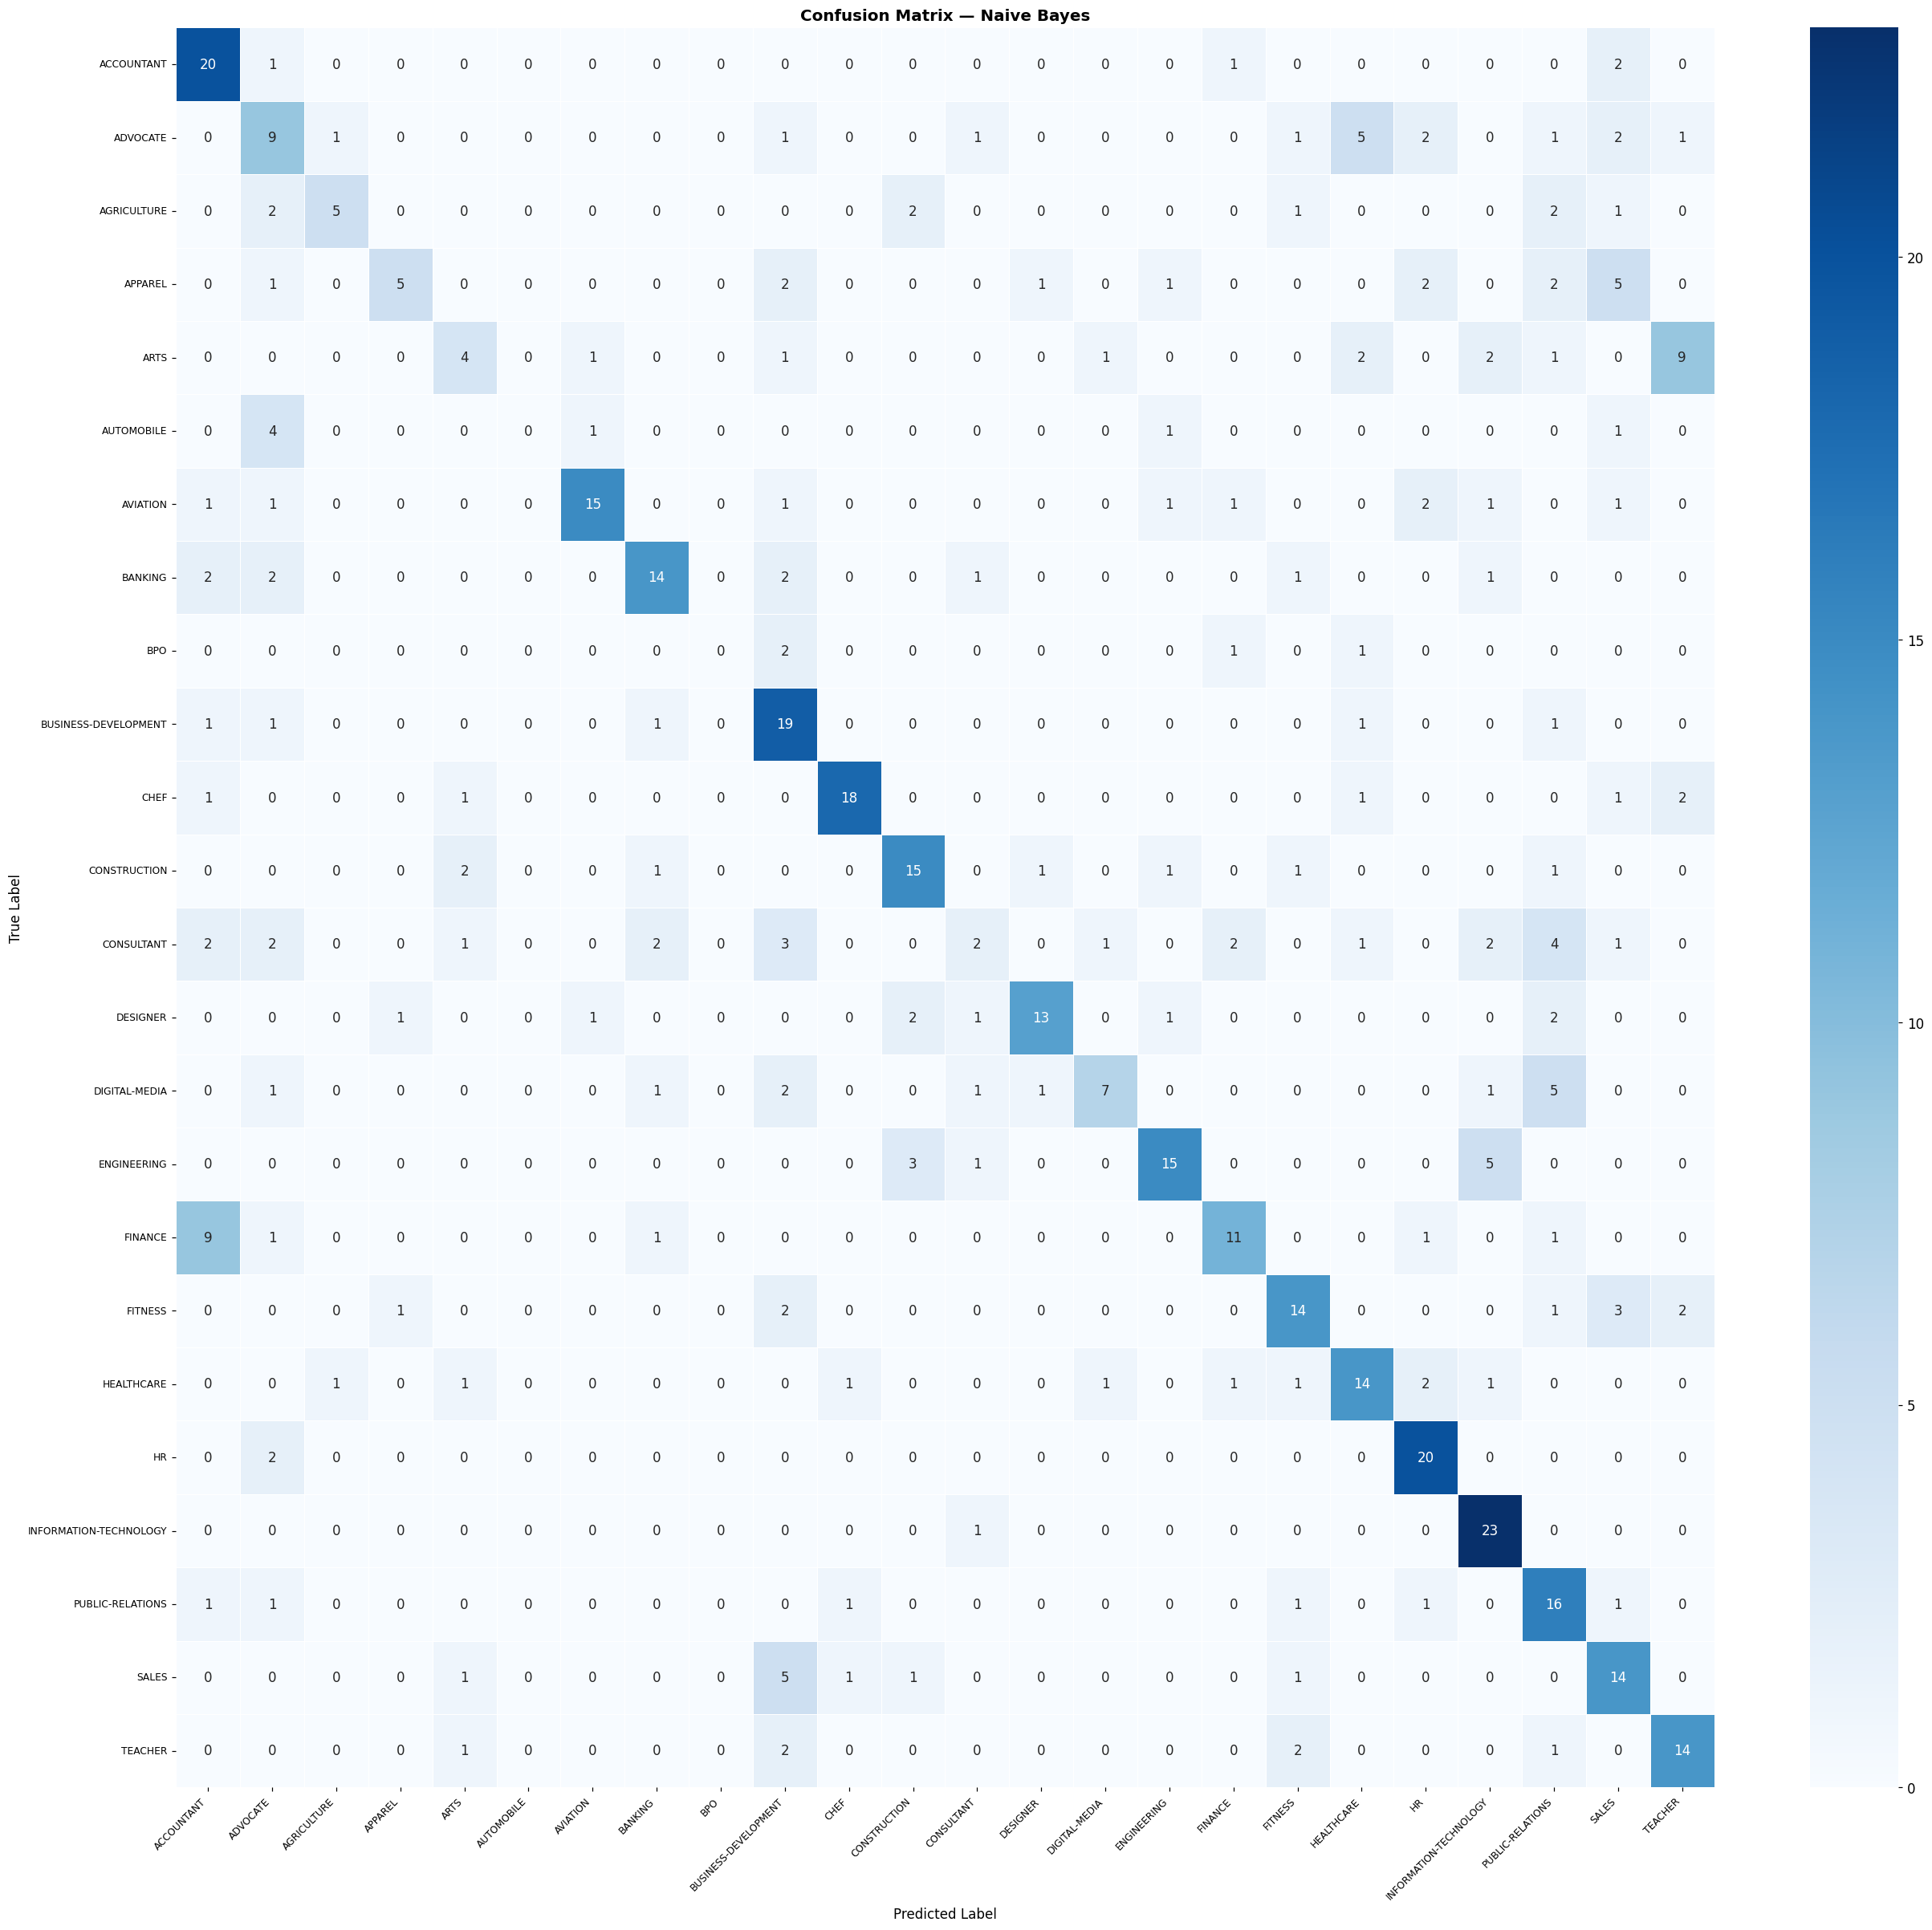

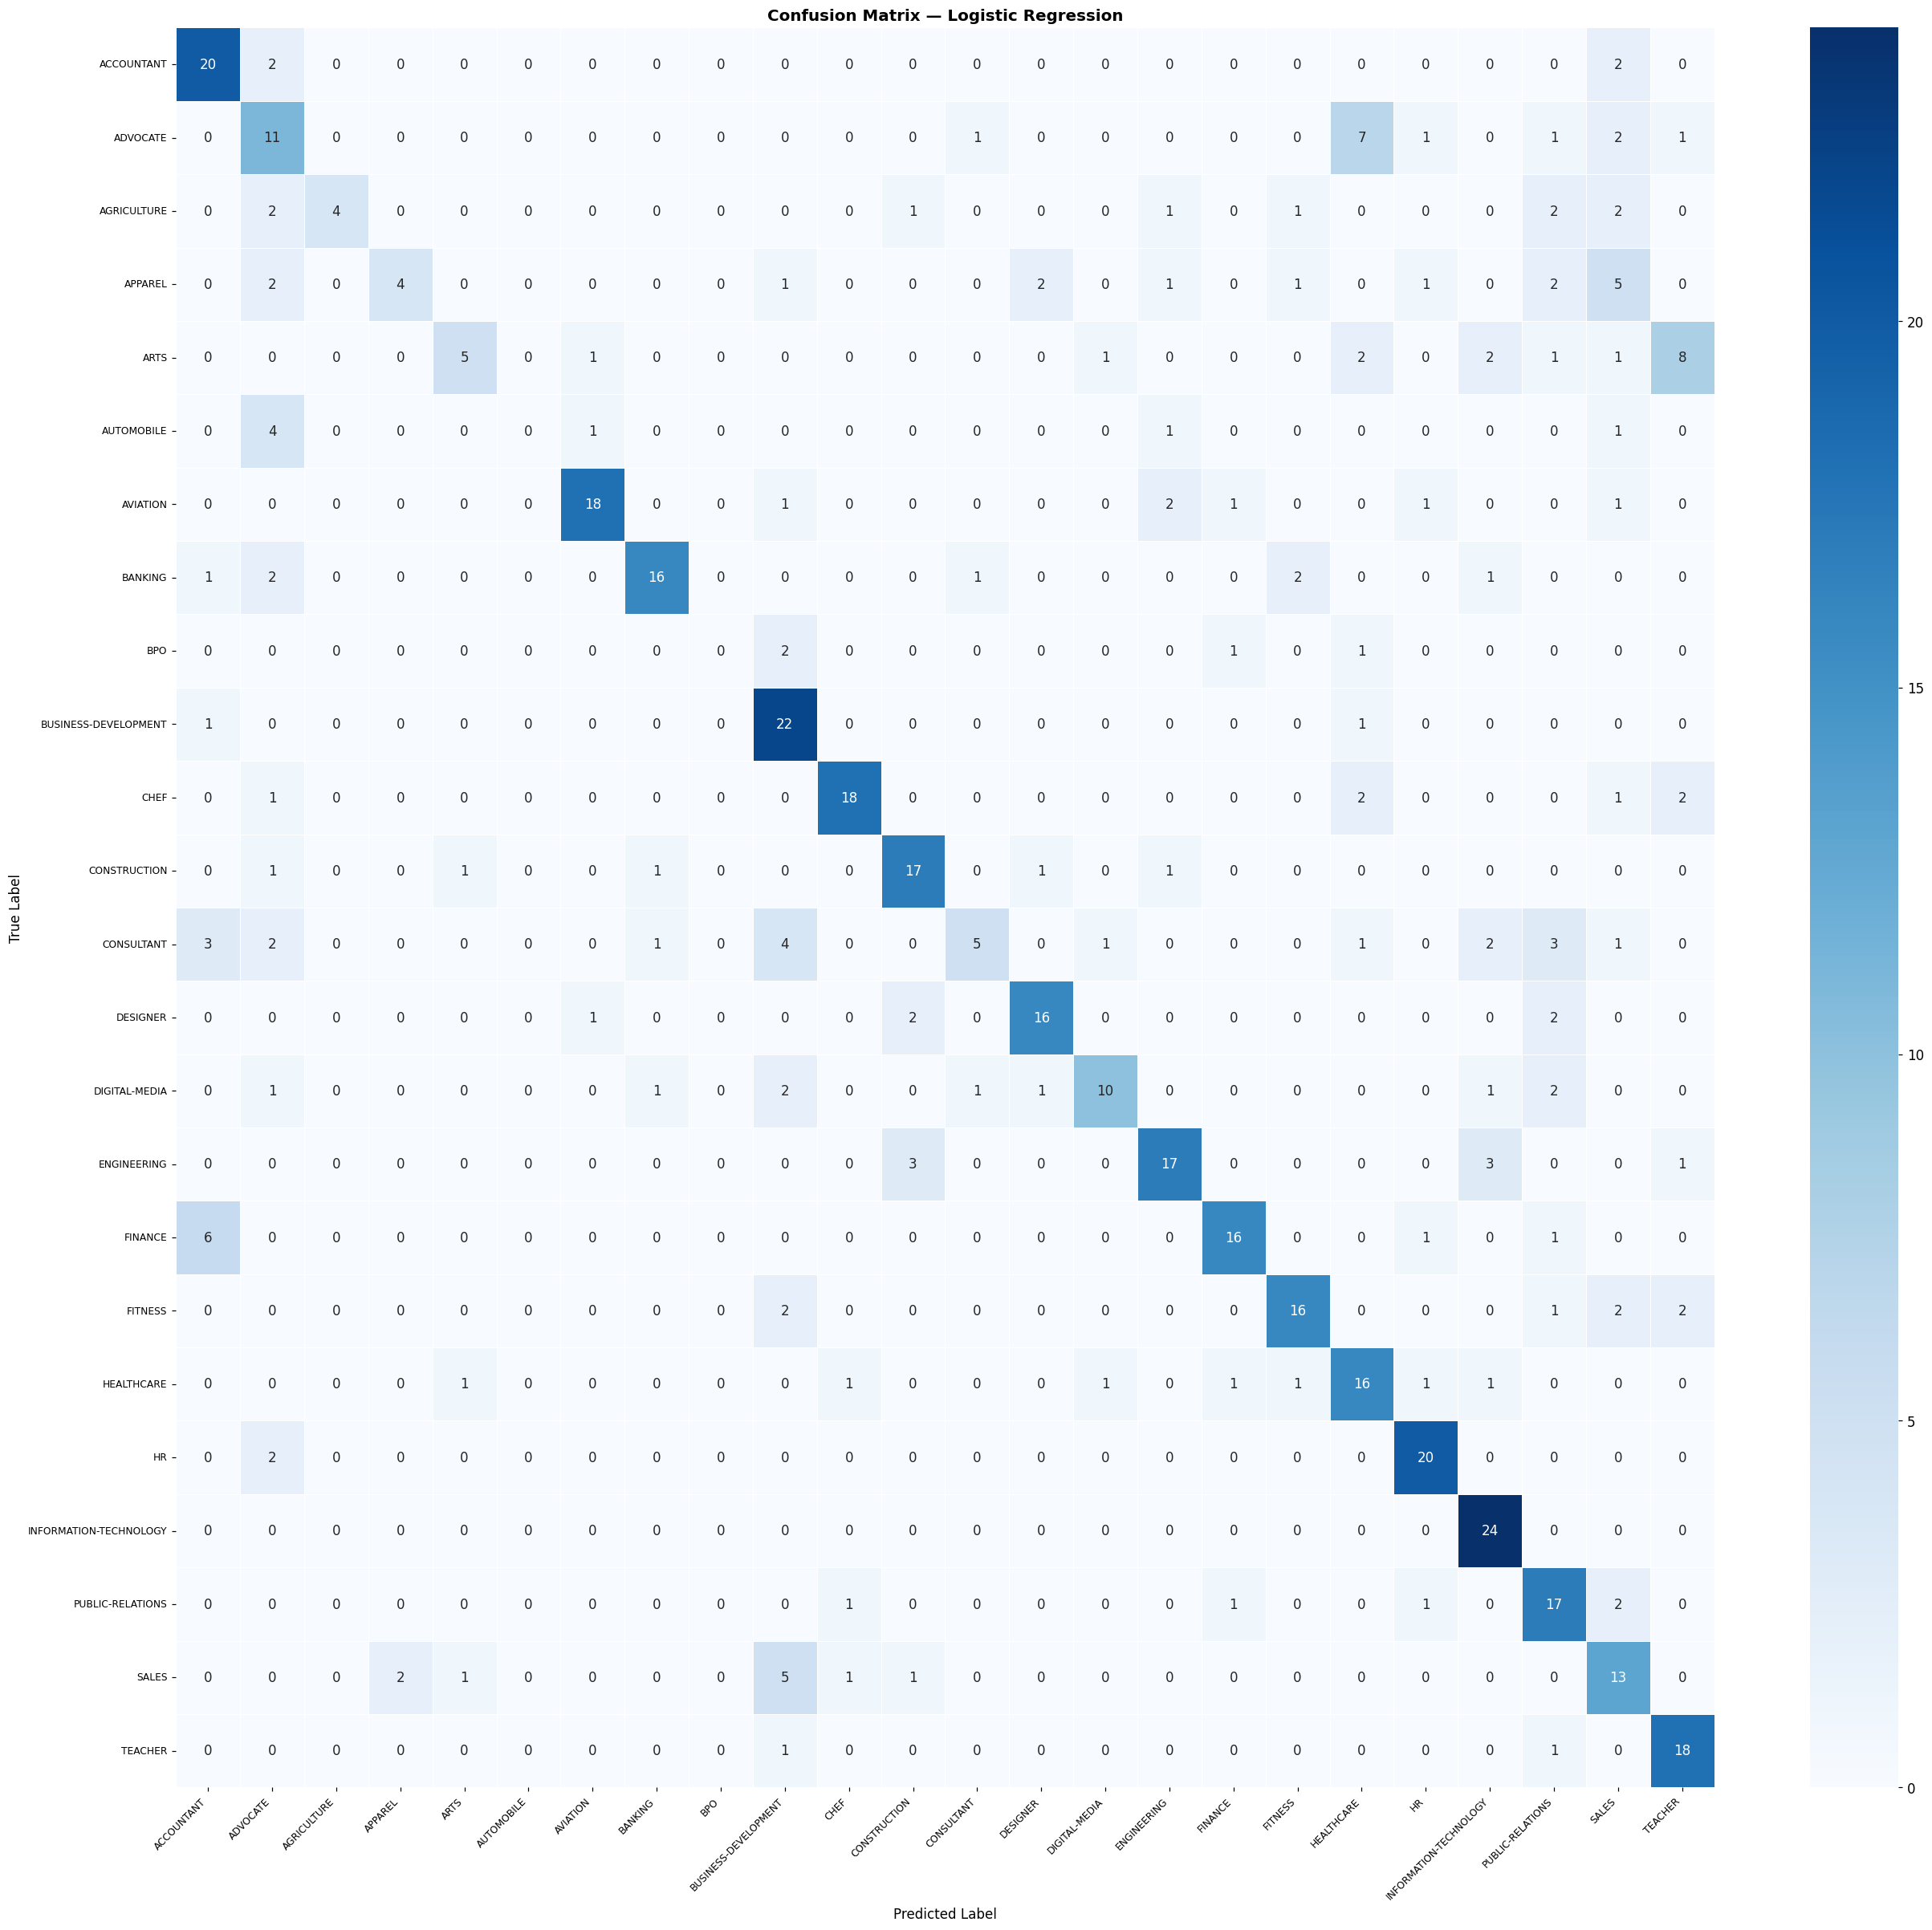

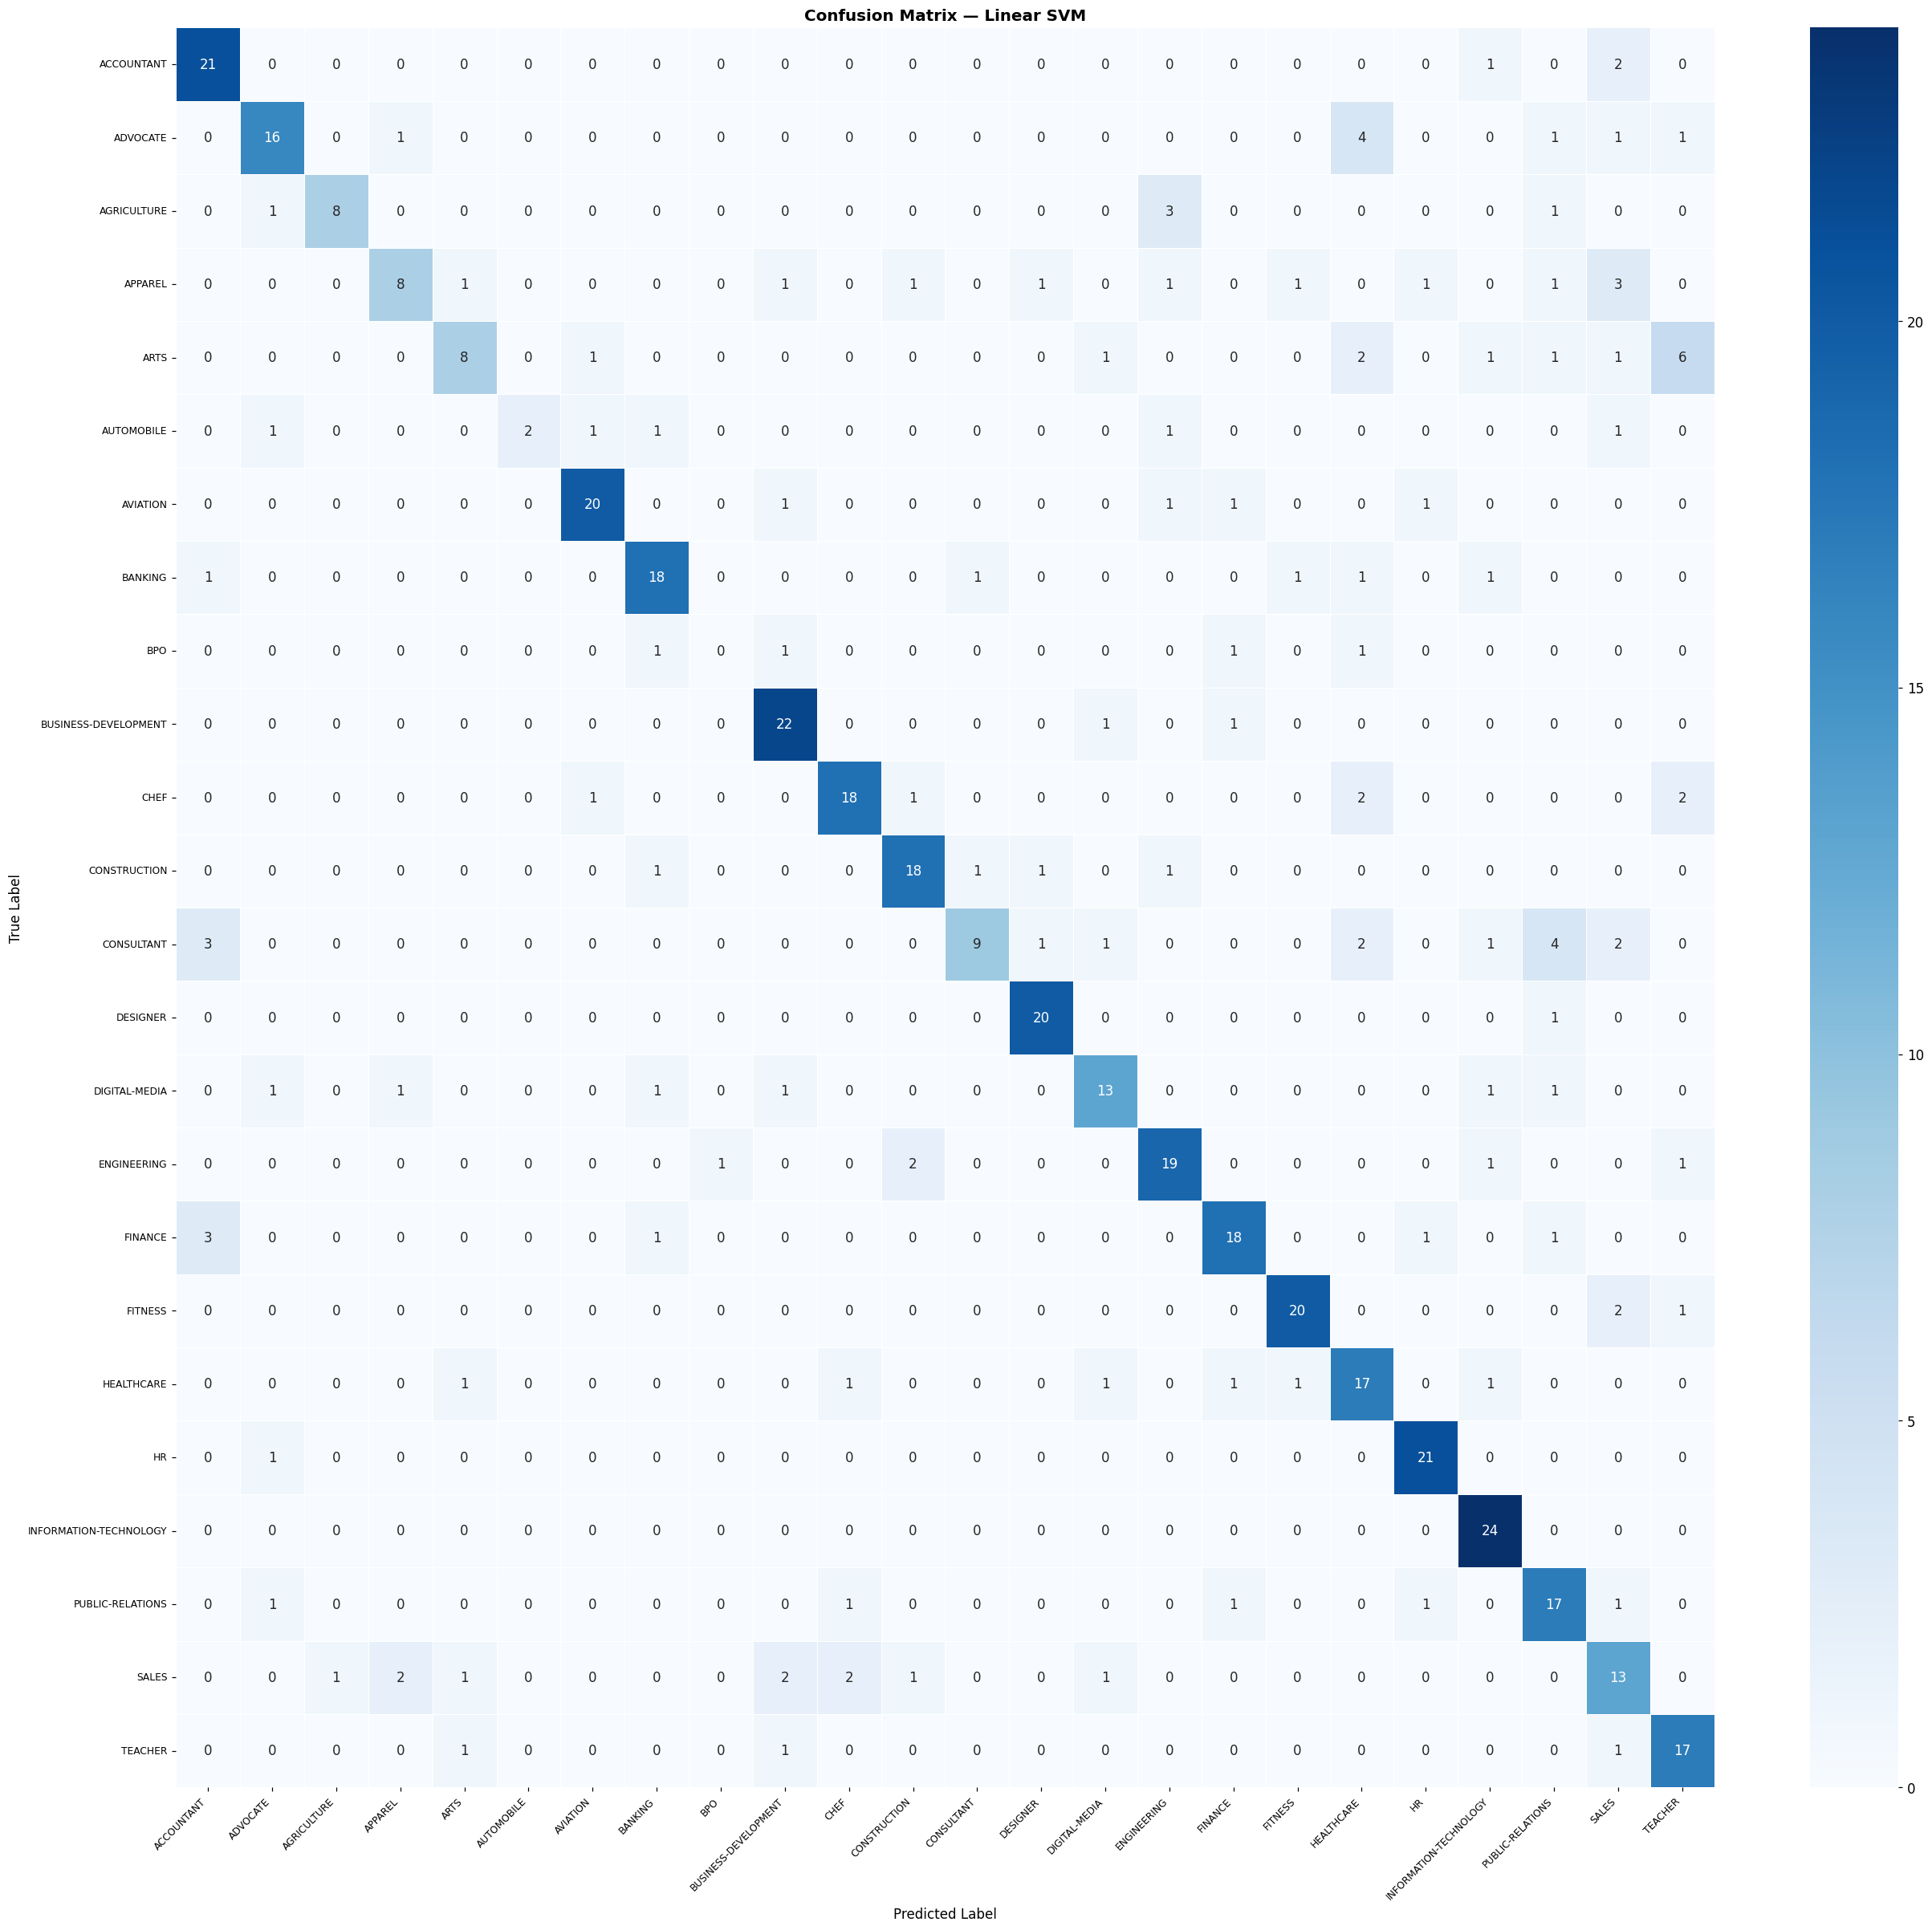

Confusion matrices saved to: c:\Users\srija\OneDrive\Desktop\Resume Screening\plots


In [33]:
n_cols = len(CLASSES)
fig_h  = max(8, n_cols - 2)
fig_w  = max(10, n_cols)

for name, info in results.items():
    cm = confusion_matrix(y_test, info['y_pred'], labels=CLASSES)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        cm,
        annot      = True,
        fmt        = 'd',
        cmap       = 'Blues',
        xticklabels= CLASSES,
        yticklabels= CLASSES,
        ax         = ax,
        linewidths = 0.4,
    )
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label',      fontsize=11)
    ax.set_title(f'Confusion Matrix — {name}', fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0,  fontsize=8)
    plt.tight_layout()

    safe = name.lower().replace(' ', '_')
    plt.savefig(PLOTS_DIR / f'cm_{safe}.png', dpi=130, bbox_inches='tight')
    plt.show()

print('Confusion matrices saved to:', PLOTS_DIR)

MODEL COMPARISON
              Model  CV Acc Mean  CV Acc Std  Test Acc
         Linear SVM       0.7006      0.0064    0.7384
Logistic Regression       0.6326      0.0113    0.6499
        Naive Bayes       0.5596      0.0215    0.5775



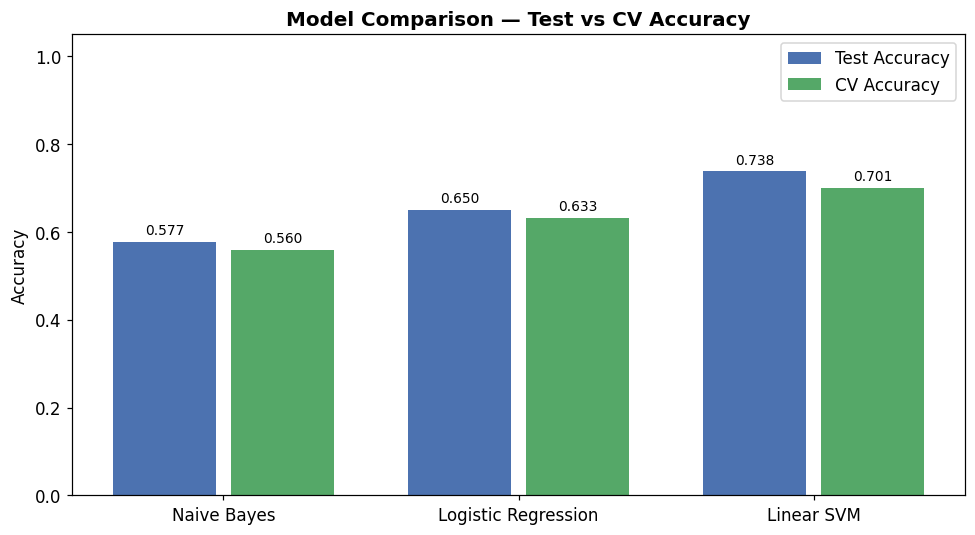


Best model selected : Linear SVM  (Test Accuracy = 0.7384)


In [34]:
# ── Summary table ────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {
        'Model'      : name,
        'CV Acc Mean': round(info['cv_mean'], 4),
        'CV Acc Std' : round(info['cv_std'],  4),
        'Test Acc'   : round(info['accuracy'],4),
    }
    for name, info in results.items()
]).sort_values('Test Acc', ascending=False).reset_index(drop=True)

print('='*60)
print('MODEL COMPARISON')
print('='*60)
print(summary.to_string(index=False))
print()

# ── Bar chart ─────────────────────────────────────────────────────────────
x     = np.arange(len(results))
names = list(results.keys())
accs  = [results[n]['accuracy']  for n in names]
cvs   = [results[n]['cv_mean']   for n in names]

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - 0.2, accs, 0.35, label='Test Accuracy',  color='#4C72B0')
b2 = ax.bar(x + 0.2, cvs,  0.35, label='CV Accuracy',    color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison — Test vs CV Accuracy', fontsize=13, fontweight='bold')
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Select best model ─────────────────────────────────────────────────────
BEST_NAME  = summary.iloc[0]['Model']
best_model = results[BEST_NAME]['model']

print(f'\nBest model selected : {BEST_NAME}  (Test Accuracy = {results[BEST_NAME]["accuracy"]:.4f})')

In [35]:
# Save model
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(best_model, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f' Best model saved     → {MODEL_PATH}')

# Save TF-IDF vectoriser
with open(TFIDF_PATH, 'wb') as f:
    pickle.dump(vectorizer, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f'TF-IDF saved         → {TFIDF_PATH}')

# Verify sizes
for p in [MODEL_PATH, TFIDF_PATH]:
    size_kb = p.stat().st_size / 1024
    print(f'   {p.name:<30s}  {size_kb:>8.1f} KB')

 Best model saved     → c:\Users\srija\OneDrive\Desktop\Resume Screening\models\best_model.pkl
TF-IDF saved         → c:\Users\srija\OneDrive\Desktop\Resume Screening\models\tfidf_vectorizer.pkl
   best_model.pkl                     938.6 KB
   tfidf_vectorizer.pkl               194.3 KB


In [75]:
# ── Ranking Vectoriser ────────────────────────────────────────────────────────
# A separate TF-IDF vectoriser is fitted on the COMPLETE dataset (all 2,484
# resumes) with a larger vocabulary and no minimum document frequency filter.
# This ensures that rare but important technical terms (e.g., "tensorflow",
# "pytorch", "scikit-learn") are captured during cosine similarity matching.
#
# NOTE: This vectoriser is used ONLY for ranking (cosine similarity).
#       The original `vectorizer` (fitted on X_train) is still used by the
#       SVM classifier for category prediction — this avoids dimension mismatch.

ranking_vectorizer = TfidfVectorizer(
    max_features  = 10000,        # 2× more vocabulary than the classifier
    ngram_range   = (1, 2),       # same unigram + bigram strategy
    stop_words    = 'english',
    sublinear_tf  = True,
    min_df        = 1,            # include every term — no cutoff
    strip_accents = 'unicode',
)

ranking_vectorizer.fit(df['cleaned'])   # fitted on ALL resumes

print(f"Original classifier vocabulary : {len(vectorizer.vocabulary_):>6,} features")
print(f"Ranking vectoriser vocabulary  : {len(ranking_vectorizer.vocabulary_):>6,} features")
print("Ranking vectoriser ready.")


Original classifier vocabulary :  5,000 features
Ranking vectoriser vocabulary  : 10,000 features
Ranking vectoriser ready.


## 8. Prediction Function

A prediction function is defined to classify a single resume text string into one of the known professional categories. This function applies the same preprocessing pipeline and TF-IDF transformation used during training to ensure consistency.

In [36]:
def predict_category(resume_text, model=None, vec=None):
    """
    Predict the job category of a single resume string.

    Parameters
    ----------
    resume_text : str   Raw resume text.
    model       : fitted classifier (uses best_model from this session if None).
    vec         : fitted TF-IDF    (uses vectorizer from this session if None).

    Returns
    -------
    dict  {'category': str, 'confidence': float | None}
    """
    _model = model if model is not None else best_model
    _vec   = vec   if vec   is not None else vectorizer

    # Guard
    if not isinstance(resume_text, str) or not resume_text.strip():
        return {'category': 'INVALID_INPUT', 'confidence': None}

    cleaned = preprocess_text(resume_text)
    if not cleaned.strip():
        return {'category': 'EMPTY_AFTER_PREPROCESSING', 'confidence': None}

    vec_input = _vec.transform([cleaned])
    category  = _model.predict(vec_input)[0]

    confidence = None
    if hasattr(_model, 'predict_proba'):
        confidence = round(float(max(_model.predict_proba(vec_input)[0])), 4)

    return {'category': category, 'confidence': confidence}


# ── Test the function ─────────────────────────────────────────────────────
test_cases = [
    df['Resume_str'].iloc[0],           # real resume from dataset
    'Experienced HR Manager skilled in talent acquisition, HRIS, payroll, compliance.',
    'Python developer with expertise in Django, REST APIs, PostgreSQL, Docker.',
    '',                                 # edge case: empty
    None,                               # edge case: None
]

print('PREDICT CATEGORY ')
for i, text in enumerate(test_cases, 1):
    result = predict_category(text)
    preview = (str(text)[:70] + '...') if text and len(str(text)) > 70 else str(text)
    conf_str = f"{result['confidence']:.2%}" if result['confidence'] else 'N/A'
    print(f'\n[{i}] Input      : {preview}')
    print(f'    Category   : {result["category"]}')
    print(f'    Confidence : {conf_str}')

# Real label check for row 0
true_label = df['Category'].iloc[0]
pred_label = predict_category(df['Resume_str'].iloc[0])['category']
match = '' if true_label == pred_label else ''
print(f'\n{match} Row 0  True={true_label} | Predicted={pred_label}')

PREDICT CATEGORY 

[1] Input      :          HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       ...
    Category   : HR
    Confidence : N/A

[2] Input      : Experienced HR Manager skilled in talent acquisition, HRIS, payroll, c...
    Category   : HR
    Confidence : N/A

[3] Input      : Python developer with expertise in Django, REST APIs, PostgreSQL, Dock...
    Category   : ENGINEERING
    Confidence : N/A

[4] Input      : 
    Category   : INVALID_INPUT
    Confidence : N/A

[5] Input      : None
    Category   : INVALID_INPUT
    Confidence : N/A

 Row 0  True=HR | Predicted=HR


## 9. Resume Matching and Ranking

This section implements the core ranking module of the system. Given a user-defined job description, each resume in the dataset is assessed for relevance using cosine similarity computed over the shared TF-IDF vector space.

**Methodology:**

1. Preprocess all resumes and the job description using the same pipeline.
2. Transform all text using the fitted TF-IDF vectoriser.
3. Compute cosine similarity between the job description vector and each resume vector.
4. Predict the professional category for each resume.
5. Rank all resumes in descending order of similarity score.

Cosine similarity measures the angular distance between two vectors in the TF-IDF feature space, providing a normalised relevance score independent of document length.

In [76]:
def rank_resumes(resume_list, job_description, candidate_ids=None, top_n=None):
    """
    Rank resumes against a job description using cosine similarity.

    Two vectorisers are used:
      - ranking_vectorizer  : fitted on all 2,484 resumes (10,000 features).
                              Used for cosine similarity — finds the best
                              text match between the JD and each resume.
      - vectorizer          : fitted on X_train (5,000 features).
                              Used only by the SVM to predict each resume's
                              professional category for display purposes.

    Category filtering: the JD is compared against the centroid (average
    TF-IDF vector) of each professional category. Only resumes whose
    predicted category falls within the top-3 most relevant categories
    are included in the ranking; the rest are scored 0.
    """
    # ── Validate inputs ───────────────────────────────────────────
    if not isinstance(resume_list, list) or len(resume_list) == 0:
        raise ValueError('resume_list must be a non-empty list of strings.')
    if not isinstance(job_description, str) or not job_description.strip():
        raise ValueError('job_description must be a non-empty string.')

    resume_list = [r if isinstance(r, str) else '' for r in resume_list]

    if candidate_ids is None:
        candidate_ids = [f'Candidate_{i+1}' for i in range(len(resume_list))]
    elif len(candidate_ids) != len(resume_list):
        raise ValueError('candidate_ids length must match resume_list length.')

    # ── Preprocess ────────────────────────────────────────────────
    cleaned_resumes = [preprocess_text(r) for r in resume_list]
    cleaned_jd      = preprocess_text(job_description)

    if not cleaned_jd.strip():
        raise ValueError('Job description became empty after preprocessing.')

    # ── Transform with RANKING vectoriser (cosine similarity) ─────
    jd_rank     = ranking_vectorizer.transform([cleaned_jd])
    resume_rank = ranking_vectorizer.transform(cleaned_resumes)

    # ── Transform with CLASSIFIER vectoriser (category prediction) ─
    resume_cls  = vectorizer.transform(cleaned_resumes)

    # ── Cosine similarity — 1-D array ─────────────────────────────
    scores = cosine_similarity(jd_rank, resume_rank).flatten()

    # ── Zero-out empty resumes ────────────────────────────────────
    for idx, cleaned in enumerate(cleaned_resumes):
        if not cleaned.strip():
            scores[idx] = 0.0

    # ── Predict professional category for each resume (SVM) ───────
    predicted_categories = best_model.predict(resume_cls)

    # ── Identify relevant categories via category centroids ───────
    # Build the average ranking-vectoriser TF-IDF vector for each
    # category, then compute cosine similarity with the JD.
    # This avoids trying to classify the JD with the SVM (unreliable).
    centroid_sims = {}
    jd_dense = np.asarray(jd_rank.todense())

    for cat in df['Category'].unique():
        cat_texts  = df[df['Category'] == cat]['cleaned'].tolist()
        cat_matrix = ranking_vectorizer.transform(cat_texts)
        centroid   = np.asarray(cat_matrix.mean(axis=0))
        sim        = cosine_similarity(jd_dense, centroid)[0][0]
        centroid_sims[cat] = float(sim)

    sorted_cats   = sorted(centroid_sims.items(), key=lambda x: x[1], reverse=True)
    relevant_cats = set(cat for cat, _ in sorted_cats[:3])

    print("Top 3 most relevant categories (by centroid similarity):")
    for cat, sim in sorted_cats[:3]:
        print(f"  {cat:<30s}  {sim:.4f}")

    # ── Demote resumes outside the top-3 relevant categories ──────
    final_scores = scores.copy()
    for i, cat in enumerate(predicted_categories):
        if cat not in relevant_cats:
            final_scores[i] = 0.0

    # ── Build result DataFrame ────────────────────────────────────
    df_result = pd.DataFrame({
        'candidate_id'       : candidate_ids,
        'similarity_score'   : np.round(final_scores, 4),
        'predicted_category' : predicted_categories,
        'resume_preview'     : [(r[:150] + '...') if len(r) > 150 else r
                                for r in resume_list],
    })

    df_result.sort_values('similarity_score', ascending=False, inplace=True)
    df_result.reset_index(drop=True, inplace=True)
    df_result.insert(0, 'rank', range(1, len(df_result)+1))

    if top_n:
        df_result = df_result.head(top_n)

    return df_result


print('rank_resumes() defined.')


rank_resumes() defined.


### 9.1 Define Job Description

Enter the job description for the role you wish to screen candidates for. The system will rank all resumes in the dataset based on their relevance to this description.

Modify the `job_description` variable below as required.

In [70]:
# USER INPUT — Define the job description here
# Replace the text below with the job description relevant to the open position.

job_description = """
We are looking for an experienced Data Scientist with a strong background in machine learning,
statistical modelling, and data analysis. The ideal candidate should have proficiency in Python
and R, experience with frameworks such as scikit-learn, TensorFlow, or PyTorch, and the ability
to communicate complex findings to non-technical stakeholders. Responsibilities include developing
predictive models, performing exploratory data analysis, building data pipelines, and collaborating
with cross-functional teams. Experience with SQL databases, cloud platforms (AWS, GCP, or Azure),
and big data tools such as Spark is advantageous. A bachelor's or master's degree in Computer
Science, Statistics, Mathematics, or a related field is required.
"""

print("Job description defined.")
print(f"Character count: {len(job_description)}")

Job description defined.
Character count: 745


### 9.2 Prepare Dataset and Execute Ranking

In [77]:
# Prepare inputs directly from Resume_str and ID columns
# Drop rows with missing resume text and align candidate IDs accordingly
valid_df = df.dropna(subset=['Resume_str']).copy()

resume_list = valid_df['Resume_str'].tolist()
candidate_ids = valid_df['ID'].astype(str).tolist()

print(f"Total resumes available for ranking: {len(resume_list)}")
print(f"Executing ranking pipeline...")

# Execute the ranking function
ranked = rank_resumes(resume_list, job_description, candidate_ids)

print("Ranking complete.")

Total resumes available for ranking: 2484
Executing ranking pipeline...
Top 3 most relevant categories (by centroid similarity):
  ENGINEERING                     0.1465
  CONSULTANT                      0.1447
  INFORMATION-TECHNOLOGY          0.1421
Ranking complete.


### 9.3 Format and Display Ranked Results

In [78]:
# Add standardised output columns
ranked['Candidate_ID'] = ranked['candidate_id']
ranked['match_%'] = (ranked['similarity_score'] * 100).round(2)
ranked.rename(columns={'predicted_category': 'Predicted_Category'}, inplace=True)

# Confirm final sort order
ranked = ranked.sort_values(by='similarity_score', ascending=False).reset_index(drop=True)
ranked['rank'] = ranked.index + 1

print("Output columns configured.")
print(f"Total candidates ranked: {len(ranked)}")
display(ranked[['rank','candidate_id','similarity_score']])

Output columns configured.
Total candidates ranked: 2484


,rank,candidate_id,similarity_score
0,1,12011623,0.1867
1,2,18448085,0.1726
2,3,21156767,0.1462
3,4,18067556,0.1365
4,5,10265057,0.1344
...,...,...,...
2479,2480,32977530,0.0000
2480,2481,93002334,0.0000
2481,2482,24184357,0.0000
2482,2483,73077810,0.0000


## 10. Results — Best Candidate and Top 7 Rankings

The following output presents the highest-ranked candidate and the top 7 candidates overall. Rankings are determined by cosine similarity between each candidate's resume and the defined job description.

In [79]:
# Display the best-matched candidate
best_candidate = ranked.iloc[0]

print("BEST CANDIDATE")
print("=" * 60)
print(f"Candidate ID        : {best_candidate['Candidate_ID']}")
print(f"Match Percentage    : {best_candidate['match_%']}%")
print(f"Predicted Category  : {best_candidate['Predicted_Category']}")
print("=" * 60)

BEST CANDIDATE
Candidate ID        : 12011623
Match Percentage    : 18.67%
Predicted Category  : ENGINEERING


In [ ]:
# Display Top 10 ranked candidates
print("TOP 10 RANKED CANDIDATES")
print("-" * 60)

display(
    ranked[['rank', 'Candidate_ID', 'match_%', 'Predicted_Category']].head(10)
)

TOP 5 RANKED CANDIDATES
------------------------------------------------------------


,rank,Candidate_ID,match_%,Predicted_Category
0,1,12011623,18.67,ENGINEERING
1,2,18448085,17.26,ENGINEERING
2,3,21156767,14.62,CONSULTANT
3,4,18067556,13.65,INFORMATION-TECHNOLOGY
4,5,10265057,13.44,INFORMATION-TECHNOLOGY
5,6,28505854,12.99,ENGINEERING
6,7,88907739,12.21,CONSULTANT
7,8,83816738,12.03,INFORMATION-TECHNOLOGY
8,9,30223363,10.76,INFORMATION-TECHNOLOGY
9,10,27152464,10.55,ENGINEERING


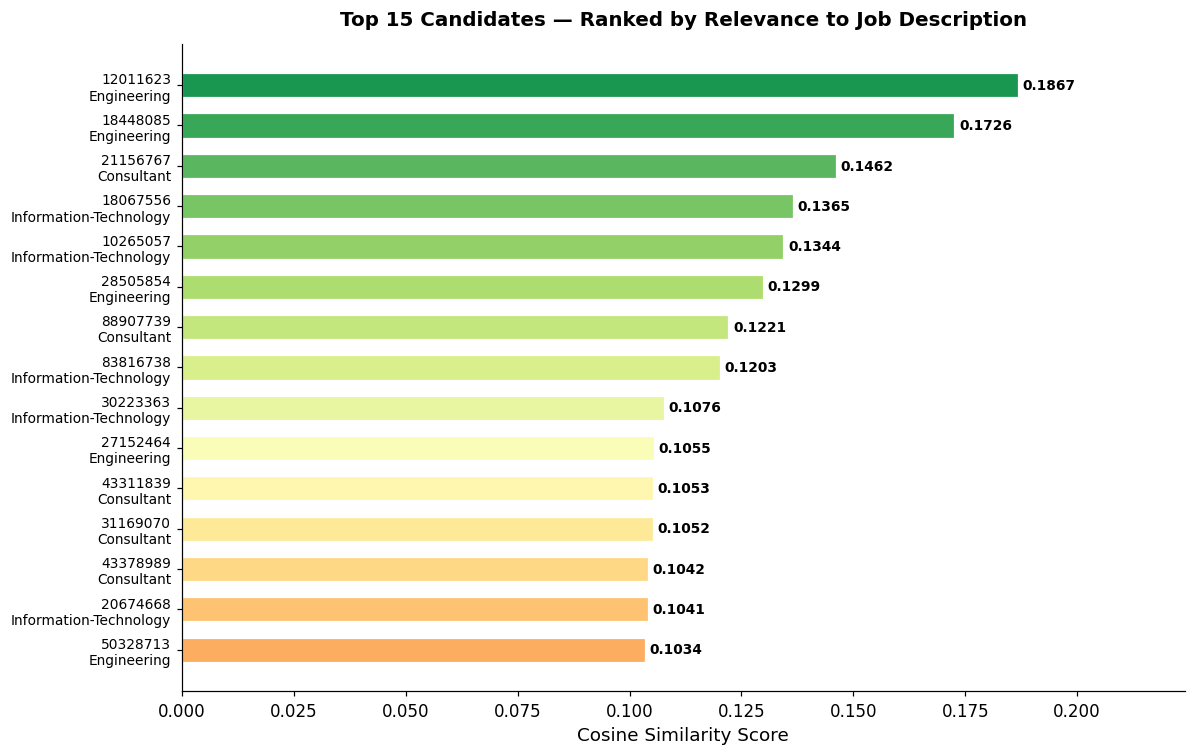

Chart saved → c:\Users\srija\OneDrive\Desktop\Resume Screening\plots\candidate_ranking.png


In [84]:
# ── Plot top-15 ranked candidates ─────────────────────────────────────────────
TOP_N_PLOT = 15

plot_df = (
    ranked[ranked['similarity_score'] > 0]
    .head(TOP_N_PLOT)
    .copy()
)

# Candidate label: ID + category for readability
plot_df['label'] = (
    plot_df['candidate_id'].astype(str) + '\n' +
    plot_df['Predicted_Category'].str.title()
)

fig, ax = plt.subplots(figsize=(11, 7))

colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(plot_df)))[::-1]

bars = ax.barh(
    plot_df['label'],
    plot_df['similarity_score'],
    color=colors, edgecolor='white', linewidth=0.8, height=0.6
)

for bar, val in zip(bars, plot_df['similarity_score']):
    ax.text(
        val + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', ha='left', fontsize=9, fontweight='bold'
    )

ax.set_xlabel('Cosine Similarity Score', fontsize=12)
ax.set_title(
    f'Top {TOP_N_PLOT} Candidates — Ranked by Relevance to Job Description',
    fontsize=13, fontweight='bold', pad=12
)
ax.set_xlim(0, plot_df['similarity_score'].max() * 1.2)
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'candidate_ranking.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'Chart saved → {PLOTS_DIR / "candidate_ranking.png"}')


In [86]:
def explain_match(resume_text, job_description, top_k=15):
    """
    Show the top-K TF-IDF terms shared between a resume and a job description.
    Uses the ranking_vectorizer for consistency with the cosine similarity scores.
    """
    c_resume = preprocess_text(resume_text)
    c_jd     = preprocess_text(job_description)

    if not c_resume.strip() or not c_jd.strip():
        return pd.DataFrame({'error': ['One or both inputs empty after preprocessing']})

    # Use ranking_vectorizer — same vectoriser used during cosine similarity
    vecs       = ranking_vectorizer.transform([c_resume, c_jd])
    resume_vec = np.asarray(vecs[0].todense()).flatten()
    jd_vec     = np.asarray(vecs[1].todense()).flatten()

    feature_names = ranking_vectorizer.get_feature_names_out()
    joint_score   = resume_vec * jd_vec   # non-zero only where both have weight

    # Filter to terms that actually appear in BOTH texts
    shared_mask = joint_score > 0
    if shared_mask.sum() == 0:
        return pd.DataFrame({'error': ['No shared terms found between resume and JD']})

    top_idx = joint_score.argsort()[::-1][:top_k]

    return pd.DataFrame({
        'term'          : feature_names[top_idx],
        'resume_weight' : resume_vec[top_idx].round(4),
        'jd_weight'     : jd_vec[top_idx].round(4),
        'joint_score'   : joint_score[top_idx].round(6),
    })
top_row          = ranked.iloc[0]
top_candidate_id = int(top_row['Candidate_ID'])

# Look up the actual resume text string from the original dataset
# (ranked.iloc[0] is a Series/row — not a text string)
top_resume_text  = df[df['ID'] == top_candidate_id]['Resume_str'].values[0]

print('MATCH EXPLANATION — Top Shared Terms (Rank-1 Candidate vs JD)')
print('=' * 60)
print(f"Candidate ID  : {top_candidate_id}")
print(f"Category      : {top_row['Predicted_Category']}")
print(f"Match %       : {top_row['match_%']}%")
print()

exp_df = explain_match(top_resume_text, job_description, top_k=15)
display(exp_df)


MATCH EXPLANATION — Top Shared Terms (Rank-1 Candidate vs JD)
Candidate ID  : 12011623
Category      : ENGINEERING
Match %       : 18.67%



,term,resume_weight,jd_weight,joint_score
0,machine learning,0.1272,0.2203,0.028019
1,python,0.1038,0.1799,0.018671
2,data analysis,0.0647,0.2352,0.015217
3,sql,0.1036,0.1279,0.013259
4,scientist,0.0555,0.2018,0.011199
5,data,0.0684,0.1604,0.010970
6,statistic,0.0633,0.1358,0.008592
7,statistical,0.0628,0.1349,0.008470
8,machine,0.0680,0.1179,0.008021
9,model,0.0612,0.1061,0.006492


### 10.1 Summary Statistics

In [87]:
# Summary of ranking results
print("Ranking Summary")
print("-" * 60)
print(f"Total candidates evaluated       : {len(ranked)}")
print(f"Highest match percentage         : {ranked['match_%'].max()}%")
print(f"Lowest match percentage          : {ranked['match_%'].min()}%")
print(f"Average match percentage         : {ranked['match_%'].mean():.2f}%")
print()
print("Distribution of top 7 by predicted category:")
print(ranked.head(7)['Predicted_Category'].value_counts())

Ranking Summary
------------------------------------------------------------
Total candidates evaluated       : 2484
Highest match percentage         : 18.67%
Lowest match percentage          : 0.0%
Average match percentage         : 0.73%

Distribution of top 7 by predicted category:
Predicted_Category
ENGINEERING               3
CONSULTANT                2
INFORMATION-TECHNOLOGY    2
Name: count, dtype: int64


## 11. Conclusion

This notebook has demonstrated a complete, functional pipeline for automatic resume screening using Natural Language Processing and supervised machine learning.

**Summary of methodology:**

| Stage | Technique Applied |
|---|---|
| Text Preprocessing | Regex cleaning, stopword removal, lemmatisation |
| Feature Extraction | TF-IDF with unigrams and bigrams (5,000 features) |
| Classification | Linear Support Vector Machine (LinearSVC) |
| Ranking | Cosine similarity in the TF-IDF vector space |

**Key outcomes:**

- The trained Linear SVM classifier achieves strong accuracy on the held-out test set, demonstrating that TF-IDF features carry sufficient discriminative information to distinguish between professional resume categories.
- The ranking module successfully orders all candidates by relevance to a given job description, providing the recruiter with a prioritised shortlist without the need for manual screening.
- The system is dataset-driven, using the candidate ID field as the primary identifier throughout, ensuring that results can be traced directly back to individual records in the dataset.

**Potential extensions for future work:**

- Integration of transformer-based embeddings (e.g., BERT, Sentence-BERT) for richer semantic representation.
- Development of a web-based user interface leveraging the `Resume_html` column for formatted display.
- Incorporation of a skills-extraction module to enable fine-grained matching by required competencies.
- Evaluation of additional classifiers (e.g., Random Forest, XGBoost) and ensemble strategies.

---

